<a href="https://colab.research.google.com/github/EngBasma02/Foundation-of-data-science-course/blob/main/Notebooks/Class%20Activities/Group_5_Gapminder_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**In-Class Team-Based Learning Activity** : Exploring Global Health & Wealth with Gapminder Data **[15 MARKS]**

---

## Objective

In this activity you will work in teams to explore **global health and economic data**.

You will work with **two separate Gapminder CSV datasets** that share a common key (`country`) and must be **joined (merged by column)** to answer meaningful questions about the relationship between wealth, health, and population.

### Datasets

Download the datasets from the Blackboard:

| File | Description |
|------|-------------|
| `Gapminder_Health.csv` | Country, Year, Continent, Life expectancy, Population |
| `gapminder_economy.csv` | Country, Year, GDP per capita |

> **Note :** Both datasets contain one row per (country, year) pair. They share `country` and `year` columns but carry **different** variables — you must **join them on `country`** to get a combined view.

### Key Columns After Joining

| Column | Dataset | Description |
|--------|---------|-------------|
| `country` | both (join key) | Country name |
| `continent` | health | Geographic region |
| `year` | both | 5-year interval (1952–2007) |
| `lifeExp` | health | Life expectancy at birth (years) |
| `pop` | health | Population |
| `gdpPercap` | economy | GDP per capita (USD, inflation-adjusted) |

### You will:
1. Load and **join (merge by columns)** the two datasets on `country`
2. **Explore** the joined data using Table methods
3. **Visualise** patterns with Table-based plots
4. **Define and use functions** with `.apply()`



## Setup – Install & Import

In [1]:
!pip install datascience

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.1/725.1 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 95.4 MB/s eta 0:00:00


In [2]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
print('Libraries loaded successfully!')

Libraries loaded successfully!


---

## Task 1 — Load and Join the Datasets **[2 marks]**

**Goal :** Load each CSV file into its own `Table`, then use `.join()` to merge them by the shared key `country`.

The `datascience` library's `.join()` works like a database inner join:

```python
merged = table_A.join('shared_column', table_B)
```

### Step 1.1 – Download and load the health dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Gapminder_Health.csv to Gapminder_Health.csv
Saving Gapminder_Economy.csv to Gapminder_Economy.csv


In [3]:
# Load the Gapminder Health dataset and assign it to 'health' table variable
health = Table.read_table('Gapminder_Health.csv')
# Show the first 5 records
health.show(5)
# Show the number of columns and number of rows
print(f"Number of columns: {health.num_columns}")
print(f"Number of rows: {health.num_rows}")

country,year,continent,lifeExp,pop
Afghanistan,1952,Asia,28.801,8.42533e+06
Afghanistan,1957,Asia,30.332,9.24093e+06
Afghanistan,1962,Asia,31.997,1.02671e+07
Afghanistan,1967,Asia,34.02,1.1538e+07
Afghanistan,1972,Asia,36.088,1.30795e+07


Number of columns: 5
Number of rows: 1704


### Step 1.2 – Load the economy dataset

In [4]:
# Load the Gapminder Economy dataset and assign it to 'economy' table variable
economy = Table.read_table('Gapminder_Economy.csv')
# Show the first 5 records
economy.show(5)
# Show the number of columns and number of rows
print(f"Number of columns: {economy.num_columns}")
print(f"Number of rows: {economy.num_rows}")

country,year,gdpPercap
Afghanistan,1952,779.445
Afghanistan,1957,820.853
Afghanistan,1962,853.101
Afghanistan,1967,836.197
Afghanistan,1972,739.981


Number of columns: 3
Number of rows: 1632


### Step 1.3 – Filter both tables to the **same year** before joining
Because each country appears multiple times (once per year), first filter to a single year so each country appears exactly once — making the join unambiguous.

> Use **year 2007** (the most recent in the dataset).


In [5]:
# Keep only 2007 records in two datasets and assign them to new Tables
health_2007 = health.where('year', 2007)
economy_2007 = economy.where('year', 2007)
# Display how many countries there are in two new tables: health_2007 and economy_2007
print(f"Number of countries in health_2007: {health_2007.num_rows}")
print(f"Number of countries in economy_2007: {economy_2007.num_rows}")

Number of countries in health_2007: 142
Number of countries in economy_2007: 136


### Step 1.4 – Join the two tables on `country`

In [8]:
# Join health data with economy data on 'country'
# health_2007 has: country, continent, year, lifeExp, pop
# economy_2007 has: country, year, gdpPercap
economy_2007 = economy_2007.drop('year') # remove duplicated year

country = health_2007.join('country', economy_2007)

country.show(5)

country,year,continent,lifeExp,pop,gdpPercap
Afghanistan,2007,Asia,43.828,3.18899e+07,974.58
Albania,2007,Europe,76.423,3.60052e+06,5937.03
Algeria,2007,Africa,72.301,3.33332e+07,6223.37
Angola,2007,Africa,42.731,1.24205e+07,4797.23
Argentina,2007,Americas,75.32,4.03019e+07,12779.4


In [9]:
country.num_columns

6

::**✏️ Question 1.1 :** How many columns does the joined table have? Explain the columns in the joined table.









There are 6 columns which are country, year, continent, lifeExp, opo,and gdpPercap. we dropped the year from economy data as its duplicated column

**✏️ Question 1.2 :** What would happen if we joined without filtering to a single year first? Why?

If we joined the two tables without filtering by year we may result in creating a table with inccorrect pairings, the table will include large data, and the data will be irrelevant.

---

## Task 2 — Explore the Joined Data Using Tables **[3 marks]**

**Goal :** Use `.select()`, `.where()`, `.group()`, and `.sort()` to extract insights.

### Step 2.1 – Select relevant columns


In [10]:
# Keep the columns in world we care about and give them clean names
# They are 'country', 'continent', 'lifeExp', 'pop', 'gdpPercap'
world = country.select('country', 'continent', 'lifeExp', 'pop', 'gdpPercap')
# show the first 5 records
world.show(5)

country,continent,lifeExp,pop,gdpPercap
Afghanistan,Asia,43.828,3.18899e+07,974.58
Albania,Europe,76.423,3.60052e+06,5937.03
Algeria,Africa,72.301,3.33332e+07,6223.37
Angola,Africa,42.731,1.24205e+07,4797.23
Argentina,Americas,75.32,4.03019e+07,12779.4


### Step 2.2 – Filter rows

In [11]:
# Create a new table, high_life, containing the countries with life expectancy above 80 years
# Display them
high_life = world.where('lifeExp', are.above(80))
high_life.show()

country,continent,lifeExp,pop,gdpPercap
Australia,Oceania,81.235,2.04342e+07,34435.4
Canada,Americas,80.653,3.33901e+07,36319.2
France,Europe,80.657,6.10839e+07,30470
Iceland,Europe,81.757,301931,36180.8
Israel,Asia,80.745,6.42668e+06,25523.3
Italy,Europe,80.546,5.81477e+07,28569.7
Japan,Asia,82.603,1.27468e+08,31656.1
New Zealand,Oceania,80.204,4.11577e+06,25185
Norway,Europe,80.196,4.62793e+06,49357.2
Spain,Europe,80.941,4.04482e+07,28821.1


In [12]:
# Create a new table, asia, containing the countries in Asia only
# Display how many countries in Asia
# Sort the countries in alphabetic order and show the first 10 of them

asia = world.where('continent', 'Asia')
print(f"Number of countries in Asia: {asia.num_rows}")
asia.sort('country').show(10)

Number of countries in Asia: 29


country,continent,lifeExp,pop,gdpPercap
Afghanistan,Asia,43.828,3.18899e+07,974.58
Bahrain,Asia,75.635,708573,29796
Bangladesh,Asia,64.062,1.50448e+08,1391.25
Cambodia,Asia,59.723,1.41319e+07,1713.78
China,Asia,72.961,1.31868e+09,4959.11
India,Asia,64.698,1.1104e+09,2452.21
Indonesia,Asia,70.65,2.23547e+08,3540.65
Iran,Asia,70.964,6.94536e+07,11605.7
Iraq,Asia,59.545,2.74996e+07,4471.06
Israel,Asia,80.745,6.42668e+06,25523.3


### Step 2.3 – Summarise data

In [13]:
# Calculate the Average life expectancy per continent
# and show them in descending order.
world.group('continent', np.mean).select('continent', 'lifeExp mean').sort('lifeExp mean', descending=True)

continent,lifeExp mean
Oceania,80.7195
Europe,77.6486
Americas,73.6081
Asia,70.4557
Africa,54.9626


In [14]:
# Calculate the Average GDP per capita per continent
# and display them in ascending order
world.group('continent', np.mean).select('continent', 'gdpPercap mean').sort('gdpPercap mean', descending=False)

continent,gdpPercap mean
Africa,3134.39
Americas,11003
Asia,11884.9
Europe,25054.5
Oceania,29810.2


**✏️ Question 2.1 :** Which continent has the highest average life expectancy in 2007? Which has the lowest?




Highest average life expectancy: Oceania: 80.71

Lowest average life expectancy: Africa: 54.96


**✏️ Question 2.2 :** Write code to find the **top 5 countries by GDP per capita** in the dataset. Are any of them surprising?



In [23]:
# Your code for Question 2.2 here

top5_gdp = world.sort('gdpPercap', descending=True).take(np.arange(5))
top5_gdp.select('country', 'continent', 'gdpPercap').show()

country,continent,gdpPercap
Norway,Europe,49357.2
Kuwait,Asia,47307
Singapore,Asia,47143.2
United States,Americas,42951.7
Ireland,Europe,40676


***Edit this cell for your answer

---

## Task 3 — Visualise the Data Using Table-Based Plots **[5 marks]**

**Goal :** Use `.barh()`, `.hist()`, and `.scatter()` to reveal patterns.

### Step 3.1 – Bar chart: average life expectancy by continent


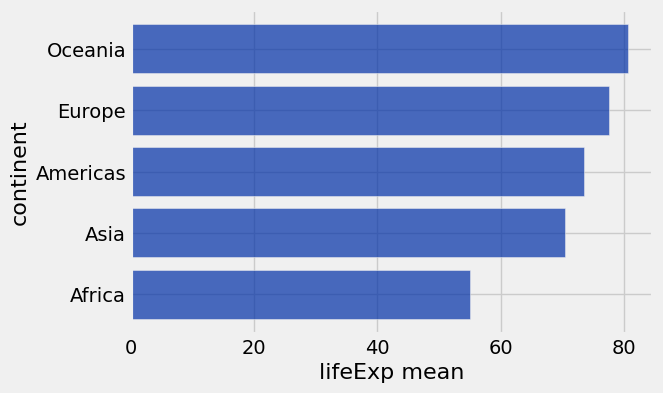

In [16]:
# Show the Average Life Expectancy by Continent (2007) using barh graphic
(world.group('continent', np.mean)
      .select('continent', 'lifeExp mean')
      .sort('lifeExp mean', descending=True)
      .barh('continent', 'lifeExp mean'))

### Step 3.2 – Histogram: distribution of GDP per capita

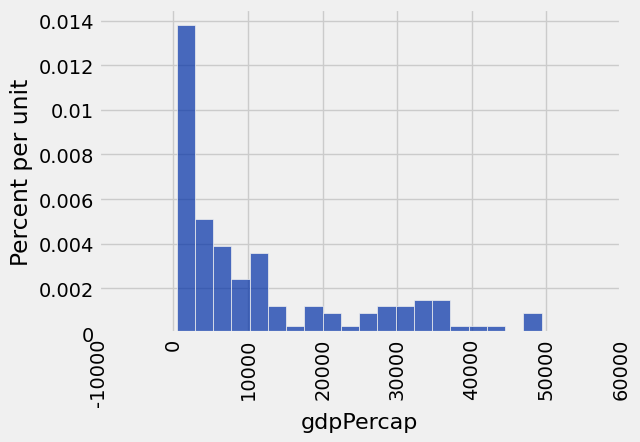

In [17]:
# Show the Distribution of GDP per Capita Across Countries (2007) using a histogram with 20 bins
world.hist('gdpPercap', bins=20)

### Step 3.3 – Scatter plot: GDP per capita vs. life expectancy

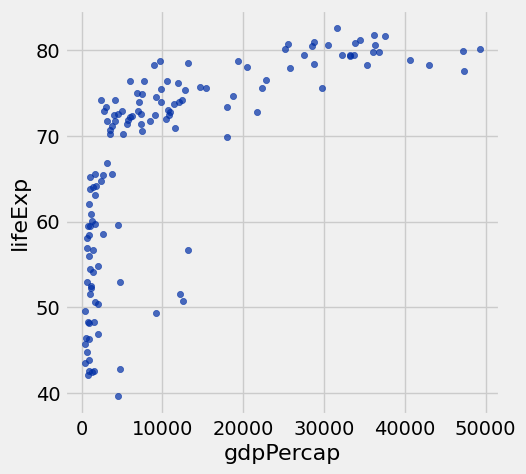

In [18]:
# Show GDP per Capita vs. Life Expectancy (2007) using a Scatter plot.
world.scatter('gdpPercap', 'lifeExp')

**✏️ Question 3.1 :** Describe the relationship between GDP per capita and life expectancy. Is it linear or non-linear? What does this suggest?






The relationship between GDP per capita and life expectancy is positive but non-linear.

As GDP per capita increases, life expectancy also increases, but not at a constant rate. At lower income levels, small increases in GDP lead to large improvements in life expectancy. However, at higher income levels, the increase in life expectancy becomes much smaller and starts to level off.

**✏️ Question 3.2 (Challenge) :** Create a bar chart showing the **5 countries with the lowest life expectancy**. What continent are most of them on?


country,continent,lifeExp,pop,gdpPercap
Swaziland,Africa,39.613,1.13307e+06,4513.48
Mozambique,Africa,42.082,1.99517e+07,823.686
Zambia,Africa,42.384,1.1746e+07,1271.21
Sierra Leone,Africa,42.568,6.14456e+06,862.541
Lesotho,Africa,42.592,2.01265e+06,1569.33


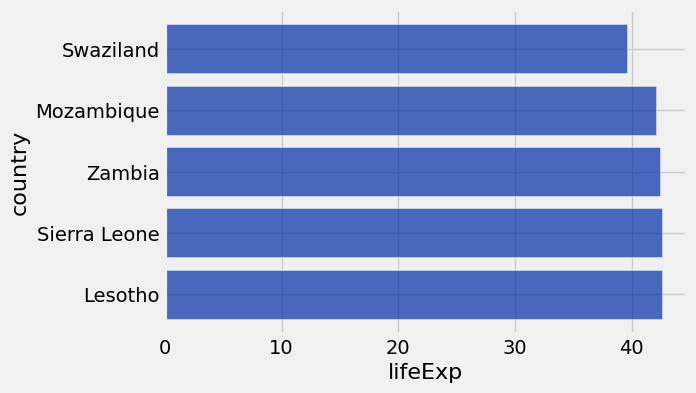

In [19]:
# Your code for Question 3.2 here
lowest_life_exp_countries = world.sort('lifeExp').take(np.arange(5))
lowest_life_exp_countries.barh('country', 'lifeExp')
lowest_life_exp_countries.show()

The countries are Swaziland, Angola, Lesotho, Sierra Leone, and Mozambique. All of the countries with the lowest life expectancy are on the Africa.

---

## Task 4 — Define and Use Functions with Tables **[5 marks]**

**Goal :** Write Python functions and apply them to table columns.

### Step 4.1 – Classify countries by income level

The World Bank uses GDP per capita thresholds to classify countries. The following defines a simplified version
and will be used to develop the function:

| Category | GDP per capita (USD) |  String to be returned |
|----------|----------------------|------------------------|
| Low income | < 1 000 |          'Low income'           |
| Lower-middle income | 1 000 – 3 999 | 'Lower-middle income'   |
| Upper-middle income | 4 000 – 12 999 | 'Upper-middle income' |
| High income | ≥ 13 000 | 'High income' |


In [20]:
# Implement income_group function
# It returns a World-Bank-style income classification based on GDP per capita.

def income_group(gdp_per_capita):
    if gdp_per_capita < 1000:
        return 'Low income'
    elif 1000 <= gdp_per_capita < 4000:
        return 'Lower-middle income'
    elif 4000 <= gdp_per_capita < 13000:
        return 'Upper-middle income'
    else:
        return 'High income'

# Quick test for your function
print(income_group(500))    # Low income
print(income_group(2500))   # Lower-middle income
print(income_group(8000))   # Upper-middle income
print(income_group(40000))  # High income

Low income
Lower-middle income
Upper-middle income
High income


In [21]:
# Apply the function to the gdpPercap column
world = world.with_column('Income Group', world.apply(income_group, 'gdpPercap'))
# Display the first 5 records
world.show(5)

country,continent,lifeExp,pop,gdpPercap,Income Group
Afghanistan,Asia,43.828,3.18899e+07,974.58,Low income
Albania,Europe,76.423,3.60052e+06,5937.03,Upper-middle income
Algeria,Africa,72.301,3.33332e+07,6223.37,Upper-middle income
Angola,Africa,42.731,1.24205e+07,4797.23,Upper-middle income
Argentina,Americas,75.32,4.03019e+07,12779.4,Upper-middle income


In [22]:
# How many countries in each income group?
# Use an appropriate function to answer this question
world.group('Income Group')

Income Group,count
High income,39
Low income,19
Lower-middle income,35
Upper-middle income,43


---

## Grading Distribution (Out of 25)

| Task | Description | Marks |
|------|-------------|-------|
| 1 | Load and join datasets with `.join()` | 2 |
| 2 | Explore with `.select()`, `.where()`, `.group()` | 3 |
| 3 | Visualise with `.barh()`, `.hist()`, `.scatter()` | 5 |
| 4 | Functions & `.apply()` | 5 |
| **Total** | | **15** |


## Submission Instructions

- **1. File Requirements**
  - **File Name :** Save your notebook as `Group_No_Gapminder_Analysis.ipynb`. Replace `Group_No` with your assigned group number.
  - **Self-Contained :** Run all cells before submitting. Include all outputs and Markdown explanations.
  - **Colab Compatibility :** Test that the notebook opens and runs via "Open in Colab":

    [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your_username/your_repo/blob/main/Group_No_Gapminder_Analysis.ipynb)

    Replace `your_username`, `your_repo`, and `Group_No` with your actual Github username, repository name, and group no, accordingly.

- **2. Group Information**
  Include the group number and all member names at the bottom of this text block.

- **3. Submission Process**
  - **GitHub :** Upload the completed notebook to a public repository with a `README.md`.
  - **Blackboard :** Submit the GitHub link **and** upload the `.ipynb` file as backup.


# Group No: [Your Group No]
## Members:
- Basma Alsaid u24102856
- Hind aljasimi
- Alanood almansoui
- fatima alfalahi
- fatima alzaabi
- ...